In [11]:
# Import Libraries
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import numpy as np
import matplotlib.pyplot as plt
import json
import cv2
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

In [2]:
# Configuration
DATA_PATH = "../Data/Scores"
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10

In [3]:
# Load Dataset
X, y, class_names = [], [], []
class_map = {}

print("[INFO] Loading dataset...")

for shape_name in os.listdir(DATA_PATH):
    shape_path = os.path.join(DATA_PATH, shape_name)
    if not os.path.isdir(shape_path):
        continue

    for score in os.listdir(shape_path):
        score_path = os.path.join(shape_path, score)
        if not os.path.isdir(score_path):
            continue

        label = f"{shape_name}_{score}"
        if label not in class_map:
            class_map[label] = len(class_map)
            class_names.append(label)

        for file in os.listdir(score_path):
            if file.lower().endswith((".png", ".jpg", ".jpeg")):
                path = os.path.join(score_path, file)
                img = cv2.imread(path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X.append(img)
                y.append(class_map[label])

X = np.array(X, dtype="float32") / 255.0
y = np.array(y)

print(f"[INFO] Dataset loaded: {X.shape[0]} samples, {len(class_map)} classes")

[INFO] Loading dataset...
[INFO] Dataset loaded: 4298 samples, 34 classes


In [4]:
# Handle case where some classes have very few samples
min_class_size = min([np.sum(y == i) for i in np.unique(y)])
print(f"[INFO] Minimum samples in any class: {min_class_size}")

[INFO] Minimum samples in any class: 1


In [5]:
# Train/Test Split
if min_class_size < 2:
    stratify = None
    print("[WARNING] Some classes have only 1 sample — stratify disabled.")
else:
    stratify = y

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify
)

y_train = to_categorical(y_train, num_classes=len(class_map))
y_test = to_categorical(y_test, num_classes=len(class_map))

print(f"[INFO] Train: {X_train.shape}, Test: {X_test.shape}")

[WARNING] Some classes have only 1 sample — stratify disabled.
[INFO] Train: (3438, 224, 224, 3), Test: (860, 224, 224, 3)


In [6]:
# Build EfficientNet Model
base_model = EfficientNetB0(include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), weights="imagenet")
base_model.trainable = False  # Freeze base layers for transfer learning

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_map), activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
print(model.summary())

2025-10-06 16:42:47.892548: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 34)             │        43,554 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,093,125 (15.61 MB)

 Trainable params: 43,554 (170.13 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

None


In [7]:
# Train Model
print("[INFO] Training EfficientNet...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

[INFO] Training EfficientNet...
Epoch 1/10


2025-10-06 16:43:26.934363: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1655808000 exceeds 10% of free system memory.


172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.1083 - loss: 2.8477 

2025-10-06 16:44:52.681348: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 414253056 exceeds 10% of free system memory.


172/172 ━━━━━━━━━━━━━━━━━━━━ 107s 585ms/step - accuracy: 0.1084 - loss: 2.8473 - val_accuracy: 0.0828 - val_loss: 2.8538
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 95s 555ms/step - accuracy: 0.1051 - loss: 2.7601 - val_accuracy: 0.0828 - val_loss: 2.8190
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 97s 566ms/step - accuracy: 0.1047 - loss: 2.7462 - val_accuracy: 0.1177 - val_loss: 2.8036
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 86s 498ms/step - accuracy: 0.1174 - loss: 2.7377 - val_accuracy: 0.1177 - val_loss: 2.8382
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 84s 489ms/step - accuracy: 0.1318 - loss: 2.7357 - val_accuracy: 0.1076 - val_loss: 2.8084
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 471ms/step - accuracy: 0.1193 - loss: 2.7185 - val_accuracy: 0.0988 - val_loss: 2.7889
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 86s 501ms/step - accuracy: 0.1287 - loss: 2.7159 - val_accuracy: 0.1076 - val_loss: 2.8290
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 83s 480ms/step - accuracy: 0.1251 - loss: 2.7480 - va

In [8]:
# Evaluate Model
print("[INFO] Evaluating model...")
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true, y_pred_classes)
print(f"[RESULT] EfficientNet Accuracy: {acc:.4f}")

print(classification_report(
    y_true, y_pred_classes,
    labels=np.arange(len(class_map)),
    target_names=class_names
))

[INFO] Evaluating model...


2025-10-06 17:20:17.848814: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 517816320 exceeds 10% of free system memory.
2025-10-06 17:20:19.804524: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 154140672 exceeds 10% of free system memory.
2025-10-06 17:20:19.862410: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 154140672 exceeds 10% of free system memory.


27/27 ━━━━━━━━━━━━━━━━━━━━ 26s 926ms/step
[RESULT] EfficientNet Accuracy: 0.1395
                      precision    recall  f1-score   support

          Triangle_0       0.00      0.00      0.00         0
          Triangle_4       0.00      0.00      0.00         8
          Triangle_5       0.00      0.00      0.00       119
              Star_3       0.00      0.00      0.00        19
              Star_2       0.00      0.00      0.00         2
              Star_0       0.00      0.00      0.00         3
              Star_4       0.00      0.00      0.00        50
              Star_5       0.00      0.00      0.00        24
              Wave_3       0.00      0.00      0.00        23
              Wave_2       0.00      0.00      0.00         2
              Wave_0       0.00      0.00      0.00         0
              Wave_4       0.00      0.00      0.00       103
            Circle_3       0.00      0.00      0.00        15
            Circle_2       0.00      0.00      0.0

/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resul

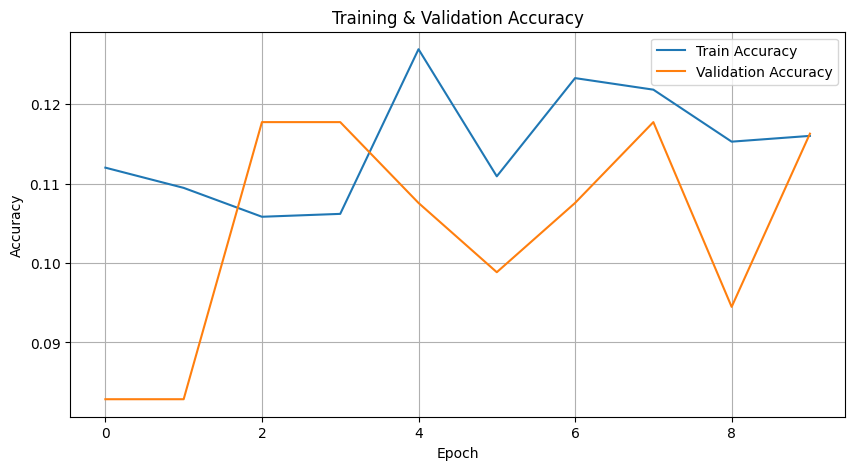

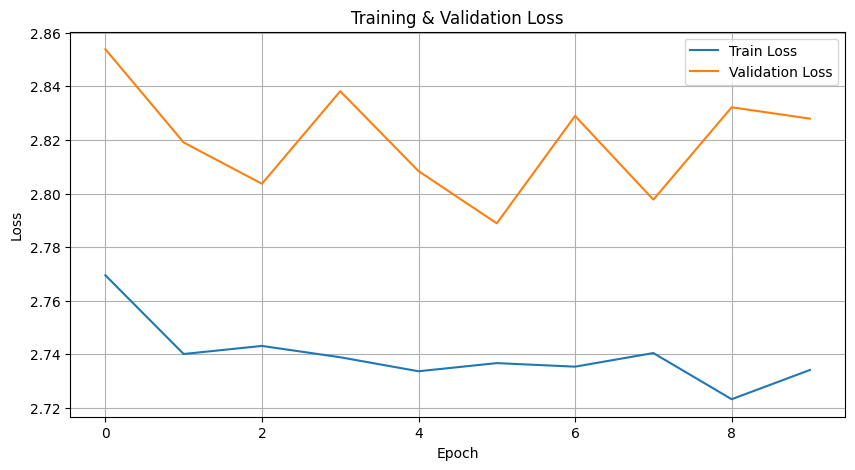

In [18]:
# Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# Save Model
SAVE_DIR = "./model_outputs_efficientnet"
os.makedirs(SAVE_DIR, exist_ok=True)

In [23]:
# Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "accuracy_plot.png"))
plt.close()

In [24]:
# Save Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "loss_plot.png"))
plt.close()

In [20]:
# Save trained model
model.save(os.path.join(SAVE_DIR, "efficientnet_bot2_model.h5"))
print("[INFO] Model saved successfully ✅")

[INFO] Model saved successfully ✅


In [21]:
# Save training history as JSON
with open(os.path.join(SAVE_DIR, "training_history.json"), "w") as f:
    json.dump(history.history, f)
print("[INFO] Training history saved as JSON ✅")

[INFO] Training history saved as JSON ✅
